In [169]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')
df=pd.read_csv("C:/Users/zinan/OneDrive/Documents/Datasets/Mall_Customers.csv")
df

,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100)
0,1,Male,19,15,39
1,2,Male,21,15,81
2,3,Female,20,16,6
3,4,Female,23,16,77
4,5,Female,31,17,40
...,...,...,...,...,...
195,196,Female,35,120,79
196,197,Female,45,126,28
197,198,Male,32,126,74
198,199,Male,32,137,18


In [170]:
df.shape

(200, 5)

In [171]:
df.columns

Index(['CustomerID', 'Gender', 'Age', 'Annual Income (k$)',
       'Spending Score (1-100)'],
      dtype='object')

In [172]:
df.head()

,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100)
0,1,Male,19,15,39
1,2,Male,21,15,81
2,3,Female,20,16,6
3,4,Female,23,16,77
4,5,Female,31,17,40


In [173]:
df.tail()

,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100)
195,196,Female,35,120,79
196,197,Female,45,126,28
197,198,Male,32,126,74
198,199,Male,32,137,18
199,200,Male,30,137,83


In [174]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 5 columns):
 #   Column                  Non-Null Count  Dtype 
---  ------                  --------------  ----- 
 0   CustomerID              200 non-null    int64 
 1   Gender                  200 non-null    object
 2   Age                     200 non-null    int64 
 3   Annual Income (k$)      200 non-null    int64 
 4   Spending Score (1-100)  200 non-null    int64 
dtypes: int64(4), object(1)
memory usage: 7.9+ KB


In [175]:
df.describe()

,CustomerID,Age,Annual Income (k$),Spending Score (1-100)
count,200.000000,200.000000,200.000000,200.000000
mean,100.500000,38.850000,60.560000,50.200000
std,57.879185,13.969007,26.264721,25.823522
min,1.000000,18.000000,15.000000,1.000000
25%,50.750000,28.750000,41.500000,34.750000
50%,100.500000,36.000000,61.500000,50.000000
75%,150.250000,49.000000,78.000000,73.000000
max,200.000000,70.000000,137.000000,99.000000


In [176]:
df.duplicated().sum()

np.int64(0)

In [177]:
df.isna().sum()

CustomerID                0
Gender                    0
Age                       0
Annual Income (k$)        0
Spending Score (1-100)    0
dtype: int64

In [178]:
df.dtypes

CustomerID                 int64
Gender                    object
Age                        int64
Annual Income (k$)         int64
Spending Score (1-100)     int64
dtype: object

<Axes: xlabel='Gender', ylabel='count'>

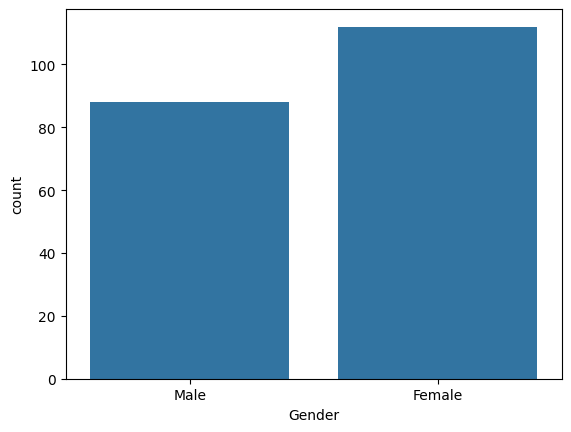

In [179]:
sns.countplot(x='Gender',data=df)

In [180]:
df.drop(['CustomerID','Gender'],axis=1,inplace=True)

In [181]:
df1=df['Spending Score (1-100)'].value_counts()
df1

Spending Score (1-100)
42    8
55    7
73    6
46    6
48    5
     ..
68    1
85    1
23    1
8     1
18    1
Name: count, Length: 84, dtype: int64

<BarContainer object of 84 artists>

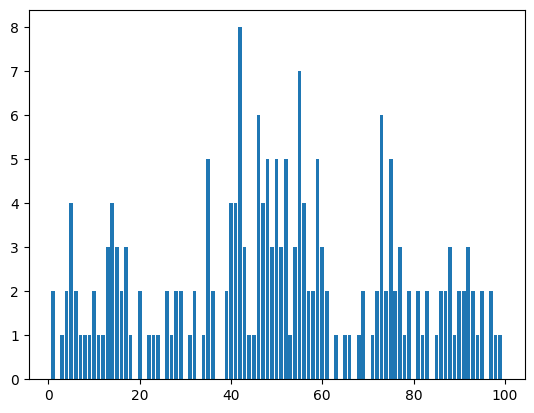

In [182]:
plt.bar(df1.index,df1.values)

In [183]:
x=df

In [184]:
#Clustering...

#Elbow Point
from sklearn.cluster import KMeans
wcss=[]
for i in range(1,11):
    data=KMeans(n_clusters=i,init='k-means++',random_state=42)
    data.fit(x)
    wcss.append(data.inertia_)

In [185]:
wcss

[308812.77999999997,
 221087.19627192983,
 158744.97108013937,
 104366.15145556201,
 97211.84353980477,
 68275.94428646986,
 51448.361262593244,
 44640.02804853042,
 42081.855308685306,
 38378.73890793208]

([<matplotlib.axis.XTick at 0x1a9063df1d0>,
 [Text(1, 0, '1'),
  Text(2, 0, '2'),
  Text(3, 0, '3'),
  Text(4, 0, '4'),
  Text(5, 0, '5'),
  Text(6, 0, '6'),
  Text(7, 0, '7'),
  Text(8, 0, '8'),
  Text(9, 0, '9'),
  Text(10, 0, '10')])

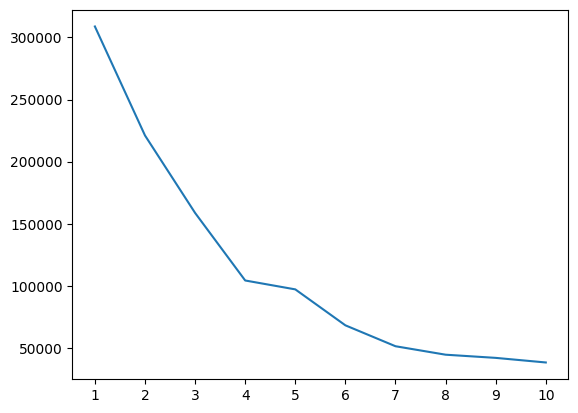

In [186]:
plt.plot(range(1,11),wcss)
plt.xticks([1,2,3,4,5,6,7,8,9,10])

In [187]:
data1=KMeans(n_clusters=7,init='k-means++',random_state=42)
data1.fit(x)
y_pred=data1.predict(x)
y_pred

array([5, 2, 5, 2, 5, 2, 5, 2, 5, 2, 5, 2, 5, 2, 5, 2, 5, 2, 5, 2, 5, 2,
       5, 2, 5, 2, 5, 2, 5, 2, 5, 2, 5, 2, 5, 2, 5, 2, 5, 2, 0, 2, 5, 2,
       5, 2, 0, 6, 6, 6, 0, 6, 6, 0, 0, 0, 0, 0, 6, 0, 0, 6, 0, 0, 0, 6,
       0, 0, 6, 6, 0, 0, 0, 0, 0, 6, 0, 6, 6, 0, 0, 6, 0, 0, 6, 0, 0, 6,
       6, 0, 0, 6, 0, 6, 6, 6, 0, 6, 0, 6, 6, 0, 0, 6, 0, 6, 0, 0, 0, 0,
       0, 6, 6, 6, 6, 6, 0, 0, 0, 0, 6, 6, 6, 4, 6, 4, 6, 4, 3, 4, 3, 4,
       6, 4, 3, 4, 3, 4, 3, 4, 3, 4, 6, 4, 3, 4, 3, 4, 3, 4, 3, 4, 3, 4,
       3, 4, 3, 4, 3, 4, 3, 4, 3, 4, 3, 4, 3, 4, 3, 4, 3, 4, 3, 4, 3, 4,
       3, 4, 3, 4, 3, 4, 3, 4, 3, 4, 3, 1, 3, 1, 3, 1, 3, 1, 3, 1, 3, 1,
       3, 1], dtype=int32)

In [188]:
x['Clusters']=y_pred
x

,Age,Annual Income (k$),Spending Score (1-100),Clusters
0,19,15,39,5
1,21,15,81,2
2,20,16,6,5
3,23,16,77,2
4,31,17,40,5
...,...,...,...,...
195,35,120,79,1
196,45,126,28,3
197,32,126,74,1
198,32,137,18,3


In [189]:
d=x['Clusters'].value_counts()
d

Clusters
0    44
6    38
3    34
4    32
2    23
5    22
1     7
Name: count, dtype: int64

In [190]:
x1=x.drop('Clusters',axis=1)
y1=x['Clusters']
x1

,Age,Annual Income (k$),Spending Score (1-100)
0,19,15,39
1,21,15,81
2,20,16,6
3,23,16,77
4,31,17,40
...,...,...,...
195,35,120,79
196,45,126,28
197,32,126,74
198,32,137,18


In [191]:
y1

0      5
1      2
2      5
3      2
4      5
      ..
195    1
196    3
197    1
198    3
199    1
Name: Clusters, Length: 200, dtype: int32

In [192]:
from sklearn.model_selection import train_test_split
x_train,x_test,y_train,y_test=train_test_split(x1,y1,test_size=0.30,random_state=42)
x_train 

,Age,Annual Income (k$),Spending Score (1-100)
169,32,87,63
97,27,60,50
31,21,30,73
12,58,20,15
35,21,33,81
...,...,...,...
106,66,63,50
14,37,20,13
92,48,60,49
179,35,93,90


In [193]:
y_train

169    4
97     6
31     2
12     5
35     2
      ..
106    0
14     5
92     0
179    4
102    0
Name: Clusters, Length: 140, dtype: int32

In [194]:
from sklearn.ensemble import RandomForestClassifier
model=RandomForestClassifier(n_estimators=200,random_state=42)
model.fit(x_train,y_train)
y_pred1=model.predict(x_test)
y_pred1

array([6, 2, 5, 3, 3, 6, 6, 3, 3, 2, 6, 3, 4, 6, 3, 4, 0, 3, 0, 6, 3, 5,
       3, 6, 6, 0, 6, 0, 4, 3, 2, 5, 0, 6, 3, 0, 4, 4, 3, 0, 0, 1, 5, 5,
       6, 1, 2, 2, 4, 0, 6, 4, 2, 3, 0, 0, 3, 0, 3, 0], dtype=int32)

In [195]:
y_train

169    4
97     6
31     2
12     5
35     2
      ..
106    0
14     5
92     0
179    4
102    0
Name: Clusters, Length: 140, dtype: int32

In [196]:
y_test

95     6
15     2
30     5
158    3
128    3
115    6
69     6
170    3
174    3
45     2
66     0
182    3
165    4
78     6
186    3
177    4
56     0
152    3
82     0
68     6
124    6
16     5
148    3
93     6
65     6
60     0
84     6
67     0
125    4
132    6
9      2
18     5
55     0
75     6
150    3
104    0
135    4
137    4
164    3
76     0
79     0
197    1
38     5
24     5
122    6
195    1
29     2
19     2
143    4
86     0
114    6
173    4
5      2
126    6
117    0
73     0
140    3
98     0
172    3
96     0
Name: Clusters, dtype: int32

In [197]:
from sklearn.metrics import confusion_matrix,accuracy_score,classification_report
cm=confusion_matrix(y_test,y_pred1)
cm

array([[13,  0,  0,  0,  0,  0,  1],
       [ 0,  2,  0,  0,  0,  0,  0],
       [ 0,  0,  6,  0,  0,  0,  0],
       [ 0,  0,  0, 12,  0,  0,  0],
       [ 0,  0,  0,  0,  7,  0,  0],
       [ 0,  0,  0,  0,  0,  5,  0],
       [ 0,  0,  0,  3,  0,  0, 11]])

<Axes: >

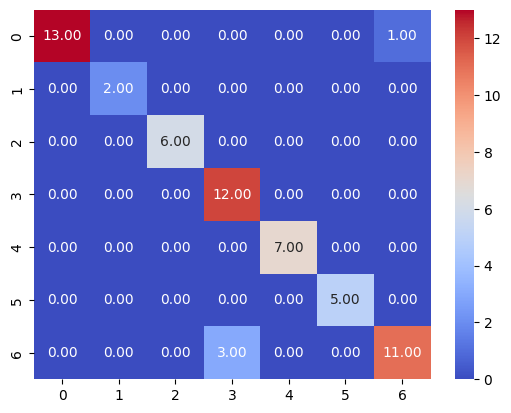

In [198]:
sns.heatmap(cm,annot=True,fmt='.2f',cmap='coolwarm')

In [199]:
score=accuracy_score(y_test,y_pred1)*100
score

93.33333333333333

In [200]:
report=classification_report(y_test,y_pred1)
print(report)

              precision    recall  f1-score   support

           0       1.00      0.93      0.96        14
           1       1.00      1.00      1.00         2
           2       1.00      1.00      1.00         6
           3       0.80      1.00      0.89        12
           4       1.00      1.00      1.00         7
           5       1.00      1.00      1.00         5
           6       0.92      0.79      0.85        14

    accuracy                           0.93        60
   macro avg       0.96      0.96      0.96        60
weighted avg       0.94      0.93      0.93        60

